# Entrega final del proyecto: respuestas a preguntas juridicas
---

- David Alejandro Agudelo Castillo - 1000220704
- Andrés Felipe Serrano Medina     - 1026574837
- Ivan Yesid Sepulveda Paez        - 1019125830

El objetivo de este proyecto es la creación de un algoritmo que permita responder a preguntas juridicas con base en un corpus de documentos que permitirían responder a dichas preguntas. La idea entonces es crear una ayuda para abogados que necesiten de encontrar el lugar puntual de un texto que pueda servirles para responder a una pregunta que tengan, de tal manera que, por ejemplo, si quieren saber qué documentos citar para crear una respuesta en su trabajo, podrían hacerlo con ayuda del algoritmo.

Para tal proyecto se partirá de un corpus que será descrito a continuación.

### **1.1. Resumen General de los Textos**

In [ ]:
!pip install requests
!pip install langdetect
!pip install unidecode
!pip install datasets pandas

import time
import requests
import pandas as pd
import spacy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from unidecode import unidecode
from collections import Counter
import textwrap
from langdetect import detect, DetectorFactory
from tqdm import tqdm


spacy.cli.download("es_core_news_sm")
nlp = spacy.load("es_core_news_sm")
print(nlp)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=4b836229d7022d30ef6672e026e21294722d0f1c582664222e357e73e2b55ed1
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from datasets import load_dataset
import pandas as pd

print("Descargando dataset...")
dataset = load_dataset("Manuel/sentencias-corte-cons-colombia-1992-2021")

df = dataset["train"].to_pandas()

print("\n--- Información del Dataset ---")
print(df)

size_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
dimensiones = df.shape

print(f"\nTamaño del dataset: {size_mb:.2f} MB en memoria")
print(f"Este dataset se compone de {dimensiones[0]} filas y {dimensiones[1]} columnas, para un total de {dimensiones[0]*dimensiones[1]} registros")

Descargando dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/249 [00:00<?, ?B/s]

Juris1992_2022.csv:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23750 [00:00<?, ? examples/s]


--- Información del Dataset ---
       Unnamed: 0                                              Texto
0               0  T-001-21\nSentencia\nT-001/21\nReferencia: Exp...
1               1  T-002-21\nSentencia T-002/21\nReferencia: Expe...
2               2  T-015-21\nSentencia T-015/21\nReferencia: Expe...
3               3  T-017-21\nSentencia\nT-017/21\nReferencia: Exp...
4               4  T-019-21\nSentencia T-019/21\nReferencia:\nExp...
...           ...                                                ...
23745       23745  SU339-11\nREPÚBLICA DE COLOMBIA\nSentencia SU-...
23746       23746  SU446-11\nREPUBLICA DE COLOMBIA\nSentencia SU4...
23747       23747  SU447-11\nREPÚBLICA DE COLOMBIA\nSentencia\nSU...
23748       23748  SU448-11\nREPÚBLICA DE COLOMBIA\nSENTENCIA SU-...
23749       23749  SU691-11\nREPÚBLICA DE COLOMBIA\nSentencia SU-...

[23750 rows x 2 columns]

Tamaño del dataset: 3045.00 MB en memoria
Este dataset se compone de 23750 filas y 2 columnas, para un total de 

Miremos el ejemplo de una de las sentencias a continuación:

In [ ]:
fila_1 = 10
fila_2 = 11

data_1 = df.loc[fila_1,'Texto']
data_2 = df.loc[fila_2,'Texto']

print(f"INFORMACIÓN DE LA FILA {fila_1+1}:")
print(data_1)


INFORMACIÓN DE LA FILA 11:
T-068-21
Sentencia T-068/21
Referencia: Expediente T-7.891.149
Acción de tutela instaurada por María y Juana[1] contra Almacenes Éxito S.A., Centro Comercial Viva y Miro Seguridad
LTDA.
Magistrada ponente:
DIANA FAJARDO RIVERA
Bogotá, D.C., diecinueve (19) de marzo de dos mil veintiuno (2021)
La Sala Primera de Revisión de la Corte Constitucional, integrada
por la magistrada Diana Fajardo Rivera, quien la preside, y los magistrados
Jorge Enrique Ibáñez Najar y Alejandro Linares Cantillo, en ejercicio de sus
competencias constitucionales y legales, específicamente las previstas en los
artículos 86 y 241 numeral 9 de la Constitución Política y en el Decreto Ley
2591 de 1991, profiere la siguiente
SENTENCIA
En el trámite de revisión de los fallos de tutela adoptados por los
correspondientes jueces de instancia, que resolvieron la acción de tutela
interpuesta por María y Juana
contra Almacenes Éxito S.A., Centro Comercial Viva y Miro Seguridad LTDA.
Aclaración pr

In [ ]:
print(f"INFORMACIÓN DE LA FILA {fila_2+1}:")
print(data_2)

INFORMACIÓN DE LA FILA 12:
T-070-21
Sentencia
T-070/21
Referencia: expediente T-7.850.880
Acción de tutela instaurada por Rosa Ayda
Tisoy Tisoy contra la Unidad Administrativa
Especial para la Atención y Reparación Integral a las Víctimas.
Magistrada
ponente:
DIANA FAJARDO
RIVERA
Bogotá, D.C., diecinueve (19) de marzo
de dos mil veintiuno (2021)
La Sala Segunda de Revisión de la
Corte Constitucional, integrada por la magistrada Diana Fajardo Rivera, quien
la preside, y los magistrados Jorge Enrique Ibáñez Najar y Alejandro Linares
Cantillo, en ejercicio de sus competencias constitucionales y legales,
específicamente de las previstas en el artículo 86 y en el numeral 9 del
artículo 241 de la Constitución Política, y en el Decreto 2591 de 1991,
profiere la siguiente
SENTENCIA
I. ANTECEDENTES
El 6 de noviembre de 2019, la
señora Rosa Ayda Tisoy Tisoy presentó acción de tutela contra la Unidad
Administrativa Especial para la Atención y Reparación Integral a las Víctimas
(en adelante, la UA

Continuemos mirando la calidad de la información de la que disponemos.

### **1.2. Resumen de la Calidad de los Textos**
---

In [ ]:
from langdetect import detect, LangDetectException
def analizar_calidad_corpus(df, columna_texto):

    ## en esta parte se analiza la cantidad de documentos y el el número de valores vacios

    print(f"Total de documentos: {len(df)}")

    nulos = df[columna_texto].isnull().sum()

    vacios = df[columna_texto].astype(str).str.strip() == ""
    total_vacios = vacios.sum()

    print(f"Valores nulos (NaN): {nulos}")
    print(f"Documentos vacíos (string vacío o solo espacios): {total_vacios}")

    # se asume que una longitud menor a 50 es sospechosa para una sentencia.
    umb_min_chars = 50

    muy_cortos = df[df[columna_texto].astype(str).str.len() < umb_min_chars]

    print(f"Documentos muy cortos (< {umb_min_chars} caracteres): {len(muy_cortos)}")

    if not muy_cortos.empty:
        print(f"Ejemplo corto: '{muy_cortos.iloc[0][columna_texto]}'")

    # Si un texto tiene demasiados símbolos vs letras, suele ser basura o error de OCR/PDF.

    def ratio_simbolos(texto):

        if not isinstance(texto, str) or len(texto) == 0: return 0

        # Contamos caracteres que no son extraños
        simbolos = len(re.findall(r'[^\w\s]', texto))

        return simbolos / len(texto)

    # Si más del 20% del texto son símbolos raros, es sospechoso

    df['ratio_ruido'] = df[columna_texto].apply(ratio_simbolos)
    ruidosos = df[df['ratio_ruido'] > 0.2]

    print(f"Documentos con alto 'ruido' (>20% símbolos): {len(ruidosos)}")

    def detectar_idioma_seguro(texto):
        try:
            # Detectamos sobre los primeros 500 caracteres para velocidad
            if not isinstance(texto, str) or len(texto.strip()) < 10:
                return "unknown"
            return detect(texto[:500])
        except LangDetectException:
            return "error"

    # Aplicamos detección
    df['idioma_detectado'] = df[columna_texto].apply(detectar_idioma_seguro)

    conteo_idiomas = df['idioma_detectado'].value_counts()
    print("Distribución de idiomas detectados:")
    print(conteo_idiomas)

    principal = conteo_idiomas.idxmax()
    porcentaje_principal = (conteo_idiomas.max() / len(df)) * 100

    print(f"\nIdioma predominante: {principal} ({porcentaje_principal:.2f}%)")

    if len(conteo_idiomas) > 1:
        otros = conteo_idiomas.drop(principal).sum()
        print(f"Se encontraron {otros} documentos en otros idiomas o no identificados.")
        if otros > 0:
            print("Filtrar el dataset para mantener solo el idioma objetivo ('es').")



posibles_columnas = ['Texto', 'text', 'body', 'content']
col_texto = next((c for c in posibles_columnas if c in df.columns), df.columns[0])

analizar_calidad_corpus(df, columna_texto=col_texto)

Total de documentos: 23750
Valores nulos (NaN): 0
Documentos vacíos (string vacío o solo espacios): 0
Documentos muy cortos (< 50 caracteres): 0
Documentos con alto 'ruido' (>20% símbolos): 0


### **1.3. Tipos de variables**
---
Consideremos el siguiente código para determinar el contenido del documento de forma descriptiva. Como tal, el dataset consta de una serie de casillas con texto y los indices para cada casilla. Frente a esto, lo que nosotros deseamos es trabajar con los textos para realizar busquedas que se énfoquen en el significado de lo que está escrito. Por lo tanto, no hay algo así como una variable objetivo a estimar, ese no es el problema a resolver.

Sin embargo, frente al contenido del documento, y por medio de una aproximacieon inicial, si se puede:

- analizar la distribución de las etiquetas, identificando si hay desbalanceo de datos.
- analizar los documentos, y determine cuál es la distribución de la longitud de los documentos a nivel carácter o palabra.
- ¿El conjunto de datos cuenta con otras variables adicionales?, de ser así, debe analizar cuáles se incorporarán en el modelo y hacer un análisis descriptivo de las mismas.

Analizando columna: 'Texto'


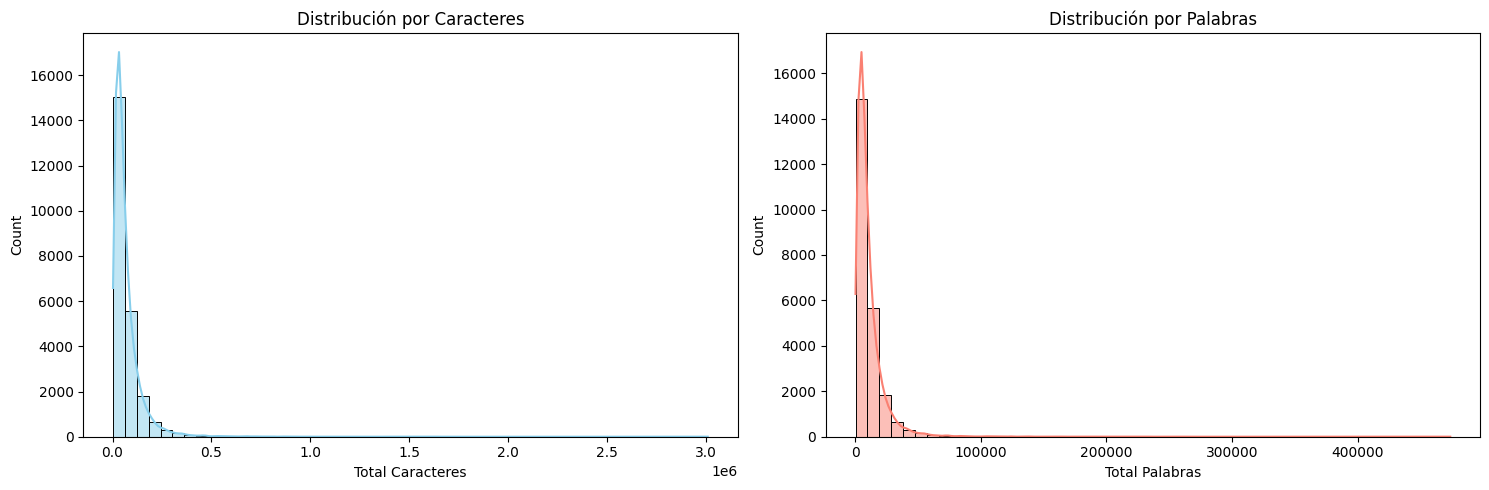

Estadísticas de Longitud (Palabras):
count     23750.000000
mean      10994.207158
std       13597.602354
min         354.000000
25%        4148.250000
50%        7475.000000
75%       13297.500000
max      473773.000000
Name: len_words, dtype: float64
VARIABLES ADICIONALES (METADATA)
Se encontraron metadatos adicionales: ['Unnamed: 0', 'ratio_ruido', 'idioma_detectado']

> Análisis de 'Unnamed: 0':
count    23750.000000
mean     11874.500000
std       6856.178783
min          0.000000
25%       5937.250000
50%      11874.500000
75%      17811.750000
max      23749.000000
Name: Unnamed: 0, dtype: float64

> Análisis de 'ratio_ruido':
count    23750.000000
mean         0.023855
std          0.003800
min          0.011709
25%          0.021256
50%          0.023474
75%          0.026035
max          0.107714
Name: ratio_ruido, dtype: float64

> Análisis de 'idioma_detectado':
   Valores únicos: 5
   Frecuencia:
idioma_detectado
es    23610
pt      132
en        4
de        2
ca        2


In [ ]:
def analizar_variables_y_distribucion(df):

    # 1. Identificar columna de texto

    col_texto = 'Texto' if 'Texto' in df.columns else df.columns[0]
    print(f"Analizando columna: '{col_texto}'")

    # 2. Calcular longitudes
    df['len_chars'] = df[col_texto].astype(str).apply(len)
    df['len_words'] = df[col_texto].astype(str).apply(lambda x: len(x.split()))

    # 3. Graficar
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(df['len_chars'], bins=50, kde=True, ax=ax[0], color='skyblue')
    ax[0].set_title("Distribución por Caracteres")
    ax[0].set_xlabel("Total Caracteres")

    sns.histplot(df['len_words'], bins=50, kde=True, ax=ax[1], color='salmon')
    ax[1].set_title("Distribución por Palabras")
    ax[1].set_xlabel("Total Palabras")

    plt.tight_layout()
    plt.show()

    print(f"Estadísticas de Longitud (Palabras):")
    print(df['len_words'].describe())

    # 4. Análisis de Metadatos
    print("VARIABLES ADICIONALES (METADATA)")

    columnas_a_excluir = [col_texto, 'len_chars', 'len_words']
    cols_metadata = [c for c in df.columns if c not in columnas_a_excluir]

    if cols_metadata:
        print(f"Se encontraron metadatos adicionales: {cols_metadata}")
        for col in cols_metadata:
            print(f"\n> Análisis de '{col}':")

            # Si es numérico
            if pd.api.types.is_numeric_dtype(df[col]):
                print(df[col].describe())
            # Si es categórico/texto
            else:
                num_unicos = df[col].nunique()
                print(f"   Valores únicos: {num_unicos}")
                # Si tiene pocos valores únicos, mostramos cuáles son
                if num_unicos < 20:
                    print(f"   Frecuencia:\n{df[col].value_counts()}")
    else:
        print("No se encontraron variables adicionales relevantes.")


analizar_variables_y_distribucion(df)


In [ ]:
dic_tipo = {
"tutela": ["tutela"],
"no tutela": []
}

dic_categorias = {
"abuso": ["abuso","agresion","maltrato","hostigamiento","violencia psicologico"],
"robo": ["robo","hurto","hurto agravar","allanamiento","sustraccion","apropiacion indebido"],
"violencia": ["violencia","lesion fisico","golpe","agresion","violento"],
"fraude": ["fraude","estafa","malversacion","apropiacion indebido","corrupcion economico","desfalco"],
"homicidio": ["homicidio","asesinato","asesinar","femicidio","feminicidio","muerte violento"],
"acoso": ["acoso","hostigamiento","intimidacion","ciberacoso","bullying"],
"corrupcion": ["corrupcion","soborno","cohecho","prevaricato","enriquecimiento ilicito"],
"trafico": ["contrabando","narcotrafico"],
"pensiones": ["pension","sustitucion pensional","prestacion economico","seguridad social"],
"salud": ["salud","medicacion","hospital","tratamiento medico","enfermedad","discapacidad"],
"laboral": ["despido"],
"otros": []
}

In [ ]:
import re
import pandas as pd
from tqdm import tqdm

tqdm.pandas(desc="Categorizando sentencias")

dic_regex = {}
for categoria, palabras_clave in dic_categorias.items():

    patron = r"\b(" + "|".join(palabras_clave) + r")\b"

    dic_regex[categoria] = re.compile(patron)


def asignar_categoria_rapido(texto):
    if pd.isna(texto):
        return "otros"

    texto_lower = str(texto).lower()


    for categoria, patron in dic_regex.items():
        if patron.search(texto_lower):
            return categoria

    return "otros"

df['categoria'] = df['Texto'].progress_apply(asignar_categoria_rapido)

Categorizando sentencias: 100%|██████████| 23750/23750 [04:54<00:00, 80.73it/s]


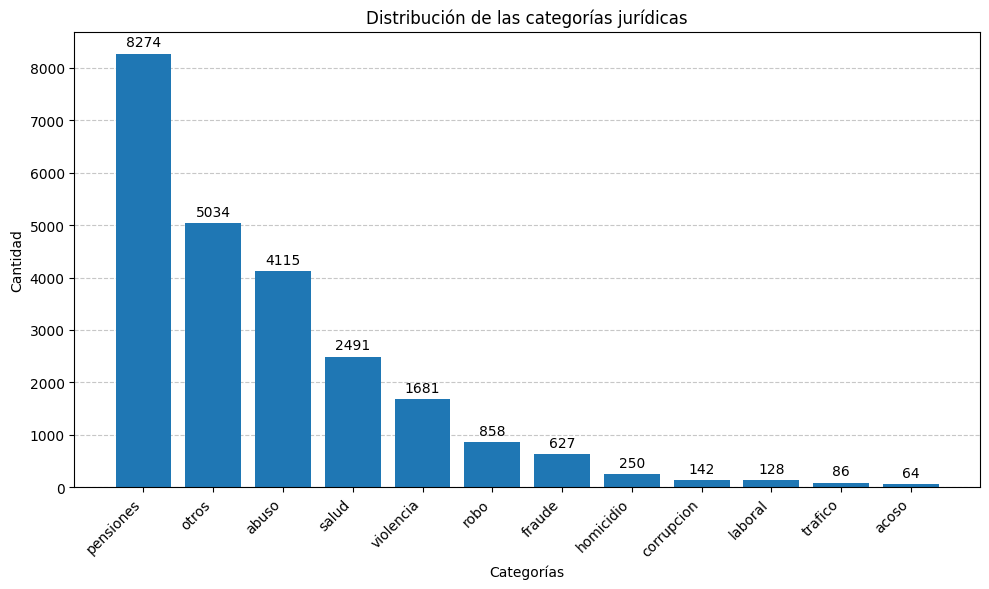

In [ ]:
variable_obj = df['categoria']
etiquetas_obj, conteo_etiquetas = np.unique(variable_obj, return_counts=True)

# Ordenar por frecuencia descendente
orden = np.argsort(conteo_etiquetas)[::-1]
etiquetas_obj = etiquetas_obj[orden]
conteo_etiquetas = conteo_etiquetas[orden]

# Crear figura
fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(etiquetas_obj, conteo_etiquetas)

# Títulos y labels
ax1.set_title('Distribución de las categorías jurídicas')
ax1.set_xlabel('Categorías')
ax1.set_ylabel('Cantidad')

# Rotación de etiquetas
plt.xticks(rotation=45, ha='right')

# Grid suave (similar a whitegrid)
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

# Anotaciones de conteo
for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f'{int(height)}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


La distribución de la variable objetivo evidencia un marcado desbalance entre las categorías jurídicas. Se observa que “pensiones” y “otros” concentran la mayor proporción de casos, mientras que categorías como “abusos” y “salud” presentan una frecuencia intermedia, y otras como “acoso”, “fraude” y “homicidio” tienen una representación mínima. Esta desigualdad en la distribución implica que el conjunto de datos no está balanceado, lo que puede afectar el desempeño de modelos de clasificación al favorecer las clases mayoritarias y limitar la capacidad de generalización en aquellas con pocos ejemplos. Además, la alta presencia de la categoría “otros” sugiere que el esquema de clasificación podría requerir refinamiento para capturar con mayor precisión la diversidad temática del corpus.

En este sentido, surge la necesidad de un preprocesamiento robusto del corpus, para categorizar de una manera más efectiva.

### **1.4. Relación Entre Variables**
---

- Analice si existe alguna relación entre las variables. Puede utilizar medidas de correlación o visualizaciones.
- Identifique si hay redundancia entre las variables para una posterior eliminación o selección.

###Análisis de relación entre variables (matriz de correlación)

Habiendo analizado previamente la estructura general del corpus y la distribución de la variable objetivo, se procede a una etapa fundamental del análisis exploratorio: la evaluación de las relaciones entre las variables cuantitativas del conjunto de datos. En este proyecto, dichas variables corresponden a características estructurales del texto, específicamente la longitud en palabras (len_words), la longitud en caracteres (len_chars) y el ratio_ruido, las cuales buscan capturar propiedades formales de los documentos jurídicos.

In [ ]:
# Construcción del DataFrame de características
caracteristicas = df[['len_words',
                      'len_chars',
                      'ratio_ruido']].copy()

# Matriz de correlación
corr_matrix = caracteristicas.corr(method='pearson')

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

KeyError: "None of [Index(['len_words', 'len_chars', 'ratio_ruido'], dtype='object')] are in the [columns]"

In [ ]:
caracteristicas = pd.DataFrame()

caracteristicas['categoria'] = df['categoria']
caracteristicas['longitud_palabras'] = df['len_words']
caracteristicas['longitud_caracteres'] = df['len_chars']
caracteristicas['ratio_ruido'] = df['ratio_ruido']

In [ ]:
def eliminar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return df[(df[columna] >= limite_inferior) &
              (df[columna] <= limite_superior)]

caracteristicas_filtrado = df[['categoria',
                                'len_words',
                                'len_chars',
                                'ratio_ruido']].copy()

for col in ['len_words', 'len_chars', 'ratio_ruido']:
    caracteristicas_filtrado = eliminar_outliers_iqr(caracteristicas_filtrado, col)

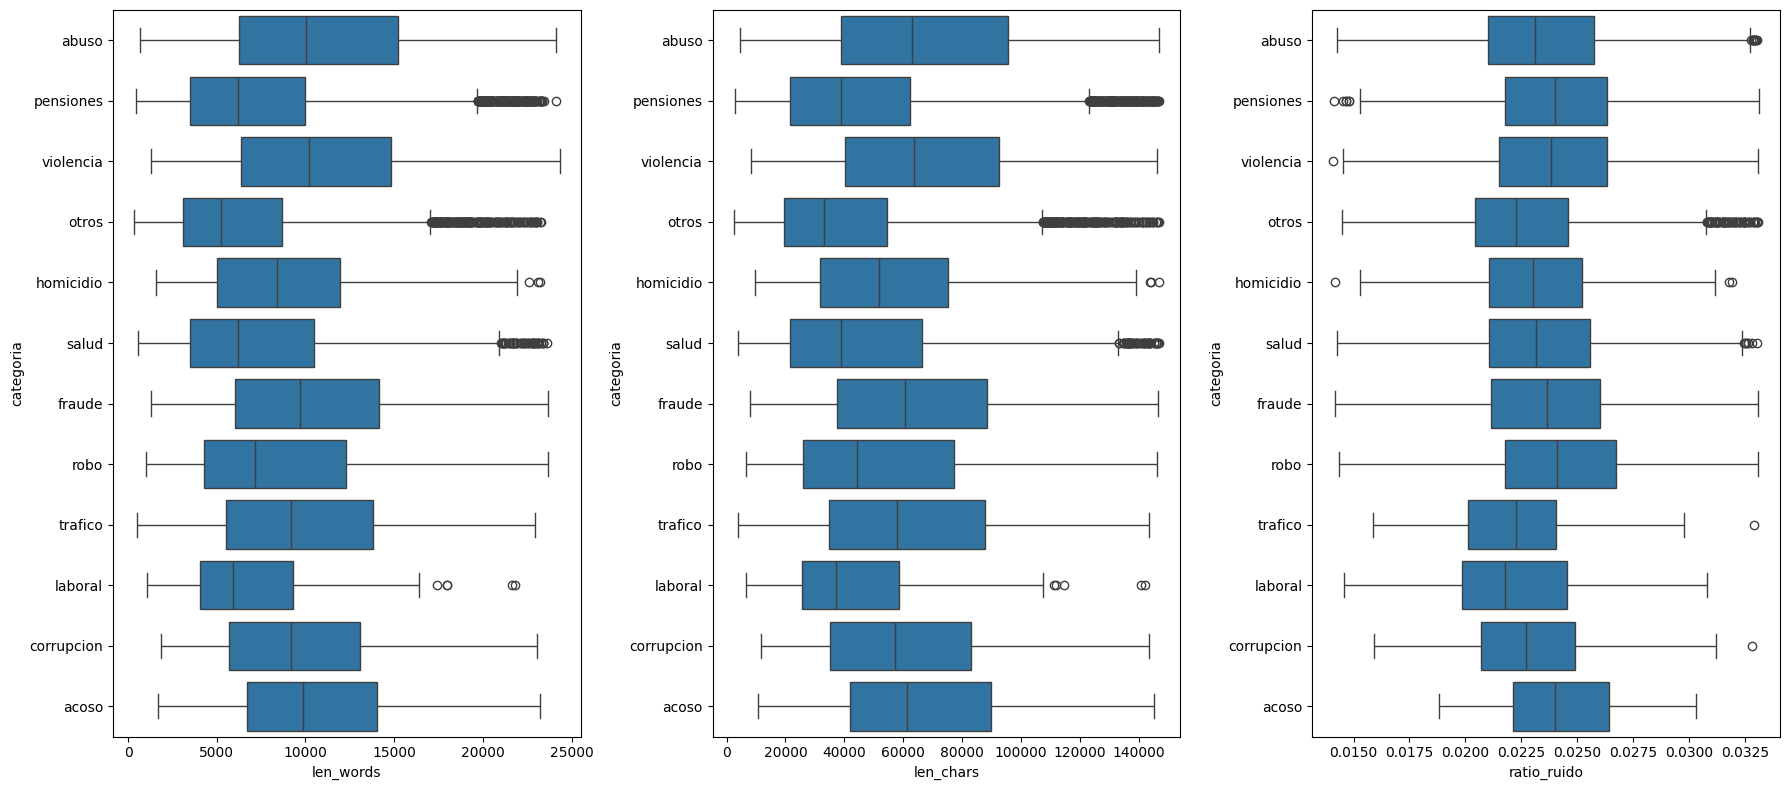

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

sns.boxplot(data=caracteristicas_filtrado,
            x='len_words',
            y='categoria',
            ax=axes[0])

sns.boxplot(data=caracteristicas_filtrado,
            x='len_chars',
            y='categoria',
            ax=axes[1])

sns.boxplot(data=caracteristicas_filtrado,
            x='ratio_ruido',
            y='categoria',
            ax=axes[2])

plt.tight_layout()
plt.show()

### **2.1. Limpieza de datos**
---

En este caso, usaremos un transformer para lograr la creación del algoritmo, en ese caso, para entregar los datos apropiados a dicho modelo, vamos a limpiar el dataset de la siguiente manera:

In [ ]:

DetectorFactory.seed = 0

tqdm.pandas()


def filtrar_solo_espanol(df, col_texto='Texto'):
    print(f"\n--- PASO 1: Detectando idiomas en '{col_texto}' ---")

    def detectar_idioma(texto):
        try:
            if pd.isna(texto) or str(texto).strip() == "":
                return "vacio"
            return detect(str(texto))
        except:
            return "desconocido"

    # Usamos progress_apply para ver cuánto falta
    df['idioma_detectado'] = df[col_texto].progress_apply(detectar_idioma)

    print("\nFrecuencia de idiomas encontrados:")
    print(df['idioma_detectado'].value_counts())

    df_limpio = df[df['idioma_detectado'] == 'es'].copy()
    df_limpio = df_limpio.drop(columns=['idioma_detectado'])

    filas_eliminadas = len(df) - len(df_limpio)
    print(f"Se eliminaron {filas_eliminadas} registros en otros idiomas o vacíos.")

    return df_limpio


def limpiar_texto_para_transformers(texto):
    """Limpia el texto manteniendo la estructura, puntuación y números vitales."""
    if not isinstance(texto, str):
        return ""

    texto = re.sub(r'[\r\n\t]+', ' ', texto)


    texto = re.sub(r'\s{2,}', ' ', texto)

    # No se eliminan palabras cortas para usasr Transformers.

    return texto.strip()



print(f"Tamaño original del dataset: {df.shape}")
TEXT_COLUMN = 'Texto' if 'Texto' in df.columns else df.columns[0]


df_espanol = filtrar_solo_espanol(df, col_texto=TEXT_COLUMN)

print("\n--- PASO 2: Limpiando formato de los documentos en español ---")
df_espanol['texto_limpio'] = df_espanol[TEXT_COLUMN].progress_apply(limpiar_texto_para_transformers)

print("\n--- EJEMPLO DE TEXTO LIMPIO ---")
fragmento = df_espanol['texto_limpio'].iloc[0][:1000]
print(textwrap.fill(fragmento, width=100))
print(f"\nTamaño final del dataset: {df_espanol.shape}")



Tamaño original del dataset: (23750, 2)

--- PASO 1: Detectando idiomas en 'Texto' ---


100%|██████████| 23750/23750 [10:10<00:00, 38.93it/s]



Frecuencia de idiomas encontrados:
idioma_detectado
es    23750
Name: count, dtype: int64
Se eliminaron 0 registros en otros idiomas o vacíos.

--- PASO 2: Limpiando formato de los documentos en español ---


100%|██████████| 23750/23750 [01:23<00:00, 284.62it/s]


--- EJEMPLO DE TEXTO LIMPIO ---
T-001-21 Sentencia T-001/21 Referencia: Expediente T-7.859.919. Acción de tutela presentada por
Francisco Javier Rincón Riaño como agente oficioso de Jhon Geiler Moreno Valero contra Capital Salud
E.P.S.-S. Procedencia: Juzgado Cuarenta y Tres (43) Penal del Circuito de Bogotá con Funciones de
Conocimiento. Asunto: agencia oficiosa, derecho a la rehabilitación de las personas en situación de
discapacidad, derecho a la salud mental, derecho al diagnóstico. Magistrada Ponente: GLORIA STELLA
ORTIZ DELGADO. Bogotá D.C., veinte (20) de enero de dos mil veintiuno (2021) La Sala Sexta de
Revisión de la Corte Constitucional, integrada por el Magistrado José Fernando Reyes Cuartas y las
Magistradas Cristina Pardo Schlesinger y Gloria Stella Ortiz Delgado, quien la preside, en ejercicio
de sus competencias constitucionales y legales, ha proferido la siguiente SENTENCIA En el trámite de
revisión del fallo de segunda instancia emitido por el Juzgado Cuarenta y Tres

## **3. Implementación del modelo**
---

Para el proyecto que acá planteamos, la idea entonces es usar transformers para encontrar los textos que respondan a las preguntas que hagamos, a continuación implementamos el modelo.

### **3.1. Importar Modelo**
---

Seleccione la librería de NLP que utilizará para el modelo e impórtelo:

En este caso se usará paraphrase-multilingual-mpnet-base-v2. Fue entrenado específicamente con millones de pares de preguntas y respuestas. Tiene una excelente comprensión semántica para conectar intenciones de búsqueda con bloques de texto.

In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### **3.2. Entrenamiento del Modelo y Selección de Hiperparámetros**
---

Si está utilizando un modelo que requiere entrenamiento, deberá entrenarlo y seleccionar un conjunto de hiperparámetros válido para el mismo:

En el caso de los transformers, estos ya vienen pre-entrenados, por lo que no hace falta dicho paso.

In [ ]:
import torch
import numpy as np
import gc

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando procesador: {device.upper()}")
model = model.to(device)

# MODIFICACIÓN CLAVE: Agregamos [:500] para tomar solo los primeros 500 textos
lista_de_textos = df_espanol['texto_limpio'].tolist()[:500]

# Configuración de los bloques
chunk_size = 250 # Bajamos el bloque a 250 para que veas el proceso dividirse en dos partes
total_textos = len(lista_de_textos)
rutas_archivos = []

print(f"Iniciando procesamiento de {total_textos} textos en bloques de {chunk_size}...\n")

for i in range(0, total_textos, chunk_size):
    # Extraemos el bloque actual
    textos_chunk = lista_de_textos[i : i + chunk_size]

    print(f"Procesando bloque del texto {i} al {i + len(textos_chunk)}...")

    # Generamos los embeddings SOLO para este bloque
    embeddings_chunk = model.encode(
        textos_chunk,
        batch_size=16,
        show_progress_bar=True,
        device=device,
        convert_to_numpy=True
    )

    # Guardamos el bloque procesado en un archivo en el disco
    nombre_archivo = f'embeddings_bloque_{i}.npy'
    np.save(nombre_archivo, embeddings_chunk)
    rutas_archivos.append(nombre_archivo)

    print(f"-> Guardado exitosamente en: {nombre_archivo}\n")

    # Liberamos la memoria antes del siguiente ciclo
    del embeddings_chunk
    del textos_chunk
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()

print("¡Listo! La prueba de 500 textos fue procesada y guardada en el disco.")

Usando procesador: CPU
Iniciando procesamiento de 23750 textos en bloques de 2000...

Procesando bloque del texto 0 al 2000...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

-> Guardado exitosamente en: embeddings_bloque_0.npy

Procesando bloque del texto 2000 al 4000...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

## **4. Evaluación o Aplicación del modelo**
---

Si entrenó un modelo, recuerde que debe reportar el desempeño del mismo sobre un conjunto de datos no visto (test). Considere que dispone de las siguientes métricas:

- **Clasificación**: accuracy, precision, recall, f1-score, AUC.
- **Regresión**: $r^2$, error cuadrático medio, error absoluto medio.
- **Agrupamiento**: coeficiente de silueta, índice de Davies-Bouldin.
- **Tópicos**: perplexity, score de coherencia.

Para evaluar lo que se ha realizado con el transformer, miremos cómo quedarían agrupados los resultados del embedding del punto anterior. Para ello tenemos el siguiente codigo:

In [ ]:
import numpy as np
import glob
from sklearn.cluster import KMeans

# 1. Buscar automáticamente todos los archivos que coincidan con el patrón
archivos_encontrados = glob.glob('embeddings_bloque_*.npy')

if not archivos_encontrados:
    print("Error: No se encontraron archivos .npy en el directorio actual.")
else:
    # PASO CRÍTICO: Ordenarlos numéricamente por el número del bloque.
    # Extraemos el número del nombre (ej: de 'embeddings_bloque_2000.npy' saca 2000)
    rutas_archivos = sorted(archivos_encontrados, key=lambda x: int(x.split('_')[-1].replace('.npy', '')))

    lista_embeddings = []
    print(f"Se encontraron {len(rutas_archivos)} bloques. Cargando desde el disco...\n")

    for archivo in rutas_archivos:
        bloque = np.load(archivo)
        lista_embeddings.append(bloque)
        print(f"Cargado: {archivo}")

    # Unimos todos los bloques verticalmente en una sola matriz
    embeddings = np.vstack(lista_embeddings)
    print(f"\n¡Embeddings cargados! Forma final de la matriz: {embeddings.shape}")

    # 2. Ejecutar tu código de KMeans
    k = 5   # número de clusters
    print(f"\nEntrenando KMeans con {k} clusters...")
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Esto puede tardar un poco dependiendo del tamaño de 'embeddings'
    clusters = kmeans.fit_predict(embeddings)

    print("¡Clustering completado exitosamente!")

Se encontraron 2 bloques. Cargando desde el disco...

Cargado: embeddings_bloque_0.npy
Cargado: embeddings_bloque_250.npy

¡Embeddings cargados! Forma final de la matriz: (500, 768)

Entrenando KMeans con 5 clusters...
¡Clustering completado exitosamente!


In [ ]:
from sklearn.metrics import silhouette_score


print("Calculando Silhouette Score... (esto puede tomar un momento)")

sil_score = silhouette_score(
    embeddings,
    clusters,
    sample_size=10000, # Ajusta este número dependiendo de tu RAM (10k - 20k es ideal)
    random_state=42
)

print(f"Silhouette score (estimado): {sil_score:.4f}")

Calculando Silhouette Score... (esto puede tomar un momento)
Silhouette score (estimado): 0.0634


In [ ]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(embeddings, clusters)

print("Davies-Bouldin index:", db_score)

Davies-Bouldin index: 2.918474945295514


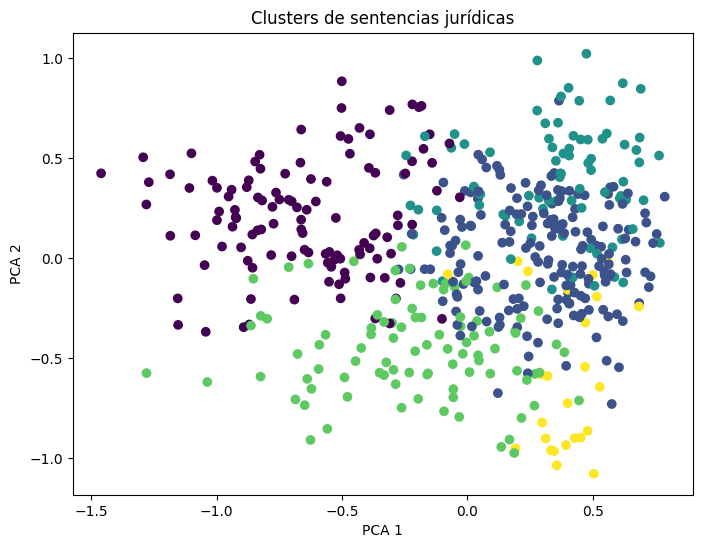

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))

plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    c=clusters
)

plt.title("Clusters de sentencias jurídicas")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

Con esto acá puede verse que, por medio de un k-means, información bastante compleja de varios textos solo quedaría dividida entre 4 clusters, lo cual no parece muy certero para responder la gran cantidad de preguntas que uno podría hacerle a los textos. Por eso, en seguida observaremos que con un modelo pre-entrenado como un transformer, se pueden generar predicciones más certeras para dar con respuestas de preguntas juridias.

In [ ]:
df_espanol.columns

Index(['Unnamed: 0', 'Texto', 'texto_limpio'], dtype='object')

In [ ]:

import textwrap
from sklearn.metrics.pairwise import cosine_similarity


lista_embeddings = [np.load(archivo) for archivo in rutas_archivos]

embeddings = np.vstack(lista_embeddings)

pregunta_usuario = "¿Cuáles son los requisitos para la pensión de invalidez?"

print(f"Generando predicción para la pregunta: '{pregunta_usuario}'\n")

# Agregamos convert_to_numpy=True para compatibilidad con sklearn
vector_pregunta = model.encode(
    [pregunta_usuario],
    convert_to_numpy=True
)

# Calculamos la similitud de la pregunta contra todos los documentos
similitudes = cosine_similarity(vector_pregunta, embeddings)[0]

# Extraemos los índices de los 3 documentos más similares
top_k = 3
indices_top = np.argsort(similitudes)[::-1][:top_k]

print("RESULTADOS DE LA BÚSQUEDA (PREDICCIÓN DEL MODELO)")
print("-" * 60)

for posicion, i in enumerate(indices_top, 1):
    score = similitudes[i]

    # Recuperamos el texto del DataFrame original
    texto_recuperado = df_espanol['texto_limpio'].iloc[i]

    # Mostramos solo los primeros 300 caracteres para no saturar la pantalla
    fragmento_mostrar = texto_recuperado[:300] + "..."

    print(f"\nTop {posicion} (Similitud: {score:.4f})")
    print(f"Texto original (Índice {i}):")
    # textwrap ajusta las líneas largas para que sean legibles en consola
    print(textwrap.fill(fragmento_mostrar, width=80))

Generando predicción para la pregunta: '¿Cuáles son los requisitos para la pensión de invalidez?'

RESULTADOS DE LA BÚSQUEDA (PREDICCIÓN DEL MODELO)
------------------------------------------------------------

Top 1 (Similitud: 0.7276)
Texto original (Índice 417):
T-238-95 Sentencia No Sentencia No. T-238/95 PENSION DE INVALIDEZ-Falta de
requisitos Procedió ajustada a la ley la Comisión de Prestaciones del ISS
Cundinamarca al negar, la pensión de invalidez solicitada por el actor y, por
consiguiente, no se han violado ni existe amenaza de violación de los der...

Top 2 (Similitud: 0.7260)
Texto original (Índice 349):
T-144-95 Sentencia No Sentencia T-144/95 PENSION DE INVALIDEZ-Derecho
Fundamental/DERECHO A LA SEGURIDAD SOCIAL La Corte ha considerado que no
obstante su naturaleza prestacional, el derecho a la seguridad social y en
especial a la pensión de invalidez, como derivado de aquel, pueda asumir en
determ...

Top 3 (Similitud: 0.7245)
Texto original (Índice 451):
T-292-95 Sente